# Reporte 07: Verificación del Endpoint `perfil_nodos` — Clasificación Garibelt

## Propósito

Verificar que `GET /api/v1/network/geolayers/profile?layer=perfil_nodos` devuelve
los campos enriquecidos correctamente tras la implementación de:
- `sistema`, `tipo_nodo`, `dim_accesibilidad` (nuevos campos de dominio)
- `dim_capilar`, `dim_centralidad` (aliases semánticos para Transport-GIS)
- `banda_color`, `dims_disponibles`, `nota_metodologica` (soporte analítico)
- `dim_eficiencia = null`, `dim_fluidez = null` (documentadas como escalares de red)

**Este notebook NO recalcula indicadores.** Solo consume el endpoint y valida su output.

---

## Guía de ejecución — prerequisitos obligatorios

Las secciones A–E requieren el servidor activo. Ejecutar en este orden:

### Paso 1 — Activar entorno y levantar servidor
```bash
# Terminal 1 — baseline
source venv/bin/activate
make run PORT=8000
```

### Paso 2 — Warmup (calentar caché — primera vez tarda 8-15 min)
```bash
# Terminal 2
# 1. Construir grafo
curl -s 'http://localhost:8000/api/v1/network/build-auto?mode=REALISTIC_INTEGRATION&tolerance_m=85' | python3 -m json.tool | head -5

# 2. Calcular T (2-5 min)
curl -s 'http://localhost:8000/api/v1/network/topological/average-travel-time' | python3 -m json.tool | head -5

# 3. Calcular B (5-8 min)
curl -s 'http://localhost:8000/api/v1/network/topological/betweenness-centrality' | python3 -m json.tool | head -5

# 4. Compilar perfil Garibelt (lento solo la primera vez)
curl -s 'http://localhost:8000/api/v1/network/topological/network-profile' | python3 -m json.tool | head -10
```

### Paso 3 — Confirmar que el perfil está en caché
```bash
curl -s 'http://localhost:8000/api/v1/network/topological/network-profile' \
  | python3 -c "import sys,json; d=json.load(sys.stdin); \
    print('dims:', len(d['data']['dimensions']), \
          '| scc_stats:', d['data'].get('scc_stats'))"
```
Resultado esperado: `dims: 5 | scc_stats: {'giant_component_nodes': 10561, ...}`

### Paso 4 — Ejecutar este notebook
Con el servidor en `:8000` y el caché caliente, ejecutar todas las celdas.

---

## Variables configurables

In [2]:
# ============================================================
# Configuración
# ============================================================
BASE_URL   = "http://localhost:8000"
MODE       = "REALISTIC_INTEGRATION"
TOLERANCE  = 85

ENDPOINT_PROFILE = f"{BASE_URL}/api/v1/network/geolayers/profile"
PARAMS = {"layer": "perfil_nodos", "mode": MODE, "tolerance_m": TOLERANCE}

# Valores de referencia baseline conocidos
EXPECTED_TOTAL_FEATURES  = 11_115
EXPECTED_AISLADOS_SCC    = 554
EXPECTED_BANDA_IDONEO    = 0      # baseline no tiene nodos idóneos

BAND_CSS = {
    "critico":       "background-color: #E74C3C; color: white",
    "debil":         "background-color: #F39C12; color: white",
    "aceptable":     "background-color: #F1C40F",
    "idoneo":        "background-color: #27AE60; color: white",
    "no_disponible": "background-color: #95A5A6; color: white",
}

In [3]:
# ============================================================
# Configuración de entorno
# ============================================================
import sys
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from IPython.display import display, HTML

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
plt.rcParams.update({'figure.dpi': 100})

# Ruta al repo para imports locales si se necesitan
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print(f'Repo root: {REPO_ROOT}')
print(f'Endpoint:  {ENDPOINT_PROFILE}')

Repo root: /Users/hcabrera/Documents/Personal_Documents
Endpoint:  http://localhost:8000/api/v1/network/geolayers/profile


---

## §A — Llamada al endpoint y parseo

In [4]:
# ============================================================
# §A — Fetch del endpoint
# ============================================================
import time

t0 = time.time()
try:
    resp = requests.get(ENDPOINT_PROFILE, params=PARAMS, timeout=60)
    resp.raise_for_status()
except requests.exceptions.ConnectionError:
    raise RuntimeError(
        "Servidor no disponible. Verificar que VFTModel esté corriendo en "
        f"{BASE_URL} y que el warmup (Pasos 1-3) esté completo."
    )
elapsed = time.time() - t0

data = resp.json()
features = data.get("features", [])

print(f'Status:       {resp.status_code}')
print(f'Tiempo resp:  {elapsed:.2f}s')
print(f'Total features: {len(features):,}')
print(f'CRS:          {data.get("crs", {})}')

# Aplanar properties a DataFrame
df_api = pd.DataFrame([f["properties"] for f in features])
print(f'\nColumnas del response ({len(df_api.columns)}):')
print(sorted(df_api.columns.tolist()))

Status:       200
Tiempo resp:  0.61s
Total features: 11,115
CRS:          {}

Columnas del response (21):
['b_banda', 'b_normalizado', 'banda_color', 'banda_dominante', 'betweenness_centrality', 'dim_accesibilidad', 'dim_capilar', 'dim_centralidad', 'dim_eficiencia', 'dim_fluidez', 'dims_disponibles', 'fc_banda', 'fc_normalizado', 'fc_total', 'id', 'indicador', 'layer', 'nombre', 'nota_metodologica', 'sistema', 'tipo_nodo']


---

## §B — Integridad de campos base

In [5]:
# ============================================================
# §B.1 — Conteo total y validación del feature count
# ============================================================
total = len(df_api)
status = '✅' if total == EXPECTED_TOTAL_FEATURES else f'⚠️  esperado {EXPECTED_TOTAL_FEATURES:,}'
print(f'Features totales: {total:,}  {status}')

# Distribución de dims_disponibles
print('\ndims_disponibles:')
print(df_api['dims_disponibles'].value_counts().sort_index().to_string())

# Nodos sin betweenness
sin_b = (df_api['nota_metodologica'] != '').sum()
status_b = '✅' if abs(sin_b - EXPECTED_AISLADOS_SCC) <= 5 else f'⚠️  esperado ≈{EXPECTED_AISLADOS_SCC}'
print(f'\nNodos con nota_metodologica != "": {sin_b:,}  {status_b}')

# dim_centralidad null debe coincidir con nota_metodologica
null_b   = df_api['dim_centralidad'].isna().sum()
status_c = '✅' if null_b == sin_b else f'⚠️  discrepancia — null_dim_centralidad={null_b}'
print(f'Nodos con dim_centralidad null:    {null_b:,}  {status_c}')

Features totales: 11,115  ✅

dims_disponibles:
dims_disponibles
1      554
2    10561

Nodos con nota_metodologica != "": 554  ✅
Nodos con dim_centralidad null:    554  ✅


In [6]:
# ============================================================
# §B.2 — Distribución de banda_dominante
# ============================================================
band_counts = df_api['banda_dominante'].value_counts().reset_index()
band_counts.columns = ['Banda', 'Nodos']
band_counts['%'] = (band_counts['Nodos'] / total * 100).round(1)

idoneo_n = band_counts.loc[band_counts['Banda'] == 'idoneo', 'Nodos'].sum()
status_i = '✅' if idoneo_n == EXPECTED_BANDA_IDONEO else f'⚠️  esperado {EXPECTED_BANDA_IDONEO}'
print(f'Nodos idóneos: {idoneo_n}  {status_i}\n')

def _color_banda_col(val):
    return BAND_CSS.get(val, '')

display(
    band_counts.style
        .map(_color_banda_col, subset=['Banda'])
        .hide(axis='index')
        .set_caption('Distribución banda_dominante — baseline')
)

# dim_eficiencia y dim_fluidez deben ser null en todos
efe_null = df_api['dim_eficiencia'].isna().all()
flu_null = df_api['dim_fluidez'].isna().all()
print(f'\ndim_eficiencia null en todos: {"✅" if efe_null else "❌"}')
print(f'dim_fluidez   null en todos: {"✅" if flu_null else "❌"}')

Nodos idóneos: 0  ✅



Banda,Nodos,%
critico,11035,99.300000
debil,78,0.700000
aceptable,2,0.000000



dim_eficiencia null en todos: ✅
dim_fluidez   null en todos: ✅


---

## §C — Integridad de campos nuevos

In [7]:
# ============================================================
# §C.1 — sistema y tipo_nodo
# ============================================================
sistema_null = df_api['sistema'].isna().sum()
print(f'Nodos con sistema null: {sistema_null}  {"✅" if sistema_null == 0 else "⚠️"}')
print('\nDistribución de sistema (top 10):')
print(df_api['sistema'].value_counts().head(10).to_string())

print('\nDistribución tipo_nodo:')
tipo_counts = df_api['tipo_nodo'].value_counts()
print(tipo_counts.to_string())

# Validar proporciones: hub_principal ≈ 25%, nodo_integrador ≈ 25%, nodo_terminal ≈ 50%
hub_pct = tipo_counts.get('hub_principal', 0) / total
print(f'\nhub_principal: {hub_pct:.1%}  (esperado ≈25% — por definición percentil p75)')

Nodos con sistema null: 0  ✅

Distribución de sistema (top 10):
sistema
RTP          4905
CC           4620
TROLE         738
MB            347
METRO         195
MEXIBÚS       157
PUMABUS        90
CBB            19
TL             18
MEXICABLE      14

Distribución tipo_nodo:
tipo_nodo
nodo_terminal      4824
hub_principal      3501
nodo_integrador    2790

hub_principal: 31.5%  (esperado ≈25% — por definición percentil p75)


Nodos con dim_accesibilidad null: 0

Estadísticas dim_accesibilidad:
count   11115.0000
mean        0.8692
std         0.2358
min         0.0102
25%         0.9004
50%         1.0000
75%         1.0000
max         1.0000


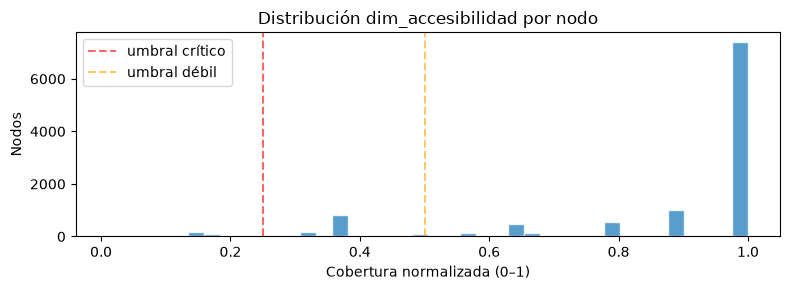


Nota: dim_accesibilidad es informativo — NO afecta banda_dominante.


In [8]:
# ============================================================
# §C.2 — dim_accesibilidad
# ============================================================
acc = df_api['dim_accesibilidad'].dropna()
acc_null = df_api['dim_accesibilidad'].isna().sum()

print(f'Nodos con dim_accesibilidad null: {acc_null}')
print(f'\nEstadísticas dim_accesibilidad:')
print(acc.describe().to_string())

# Histograma
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(acc, bins=40, color='#2E86C1', alpha=0.8, edgecolor='white')
ax.set_title('Distribución dim_accesibilidad por nodo')
ax.set_xlabel('Cobertura normalizada (0–1)')
ax.set_ylabel('Nodos')
ax.axvline(0.25, color='red',    linestyle='--', alpha=0.6, label='umbral crítico')
ax.axvline(0.50, color='orange', linestyle='--', alpha=0.6, label='umbral débil')
ax.legend()
plt.tight_layout()
plt.show()

print('\nNota: dim_accesibilidad es informativo — NO afecta banda_dominante.')

In [9]:
# ============================================================
# §C.3 — banda_color
# ============================================================
COLOR_MAP = {
    "critico":       "#E74C3C",
    "debil":         "#F39C12",
    "aceptable":     "#F1C40F",
    "idoneo":        "#27AE60",
    "no_disponible": "#95A5A6",
}

# Verificar que banda_color corresponde a banda_dominante
df_api['color_esperado'] = df_api['banda_dominante'].map(COLOR_MAP)
color_ok = (df_api['banda_color'] == df_api['color_esperado']).all()
print(f'banda_color consistente con banda_dominante: {"✅" if color_ok else "❌"}')

# Nodos con banda_color vacío o nulo
color_null = df_api['banda_color'].isna().sum()
print(f'Nodos con banda_color null: {color_null}  {"✅" if color_null == 0 else "⚠️"}')

banda_color consistente con banda_dominante: ✅
Nodos con banda_color null: 0  ✅


---

## §D — Consistencia interna del endpoint

In [10]:
# ============================================================
# §D.1 — banda_dominante vs fc_banda / b_banda
# Regla: banda_dominante = min(fc_banda, b_banda) para nodos con B(v)
#        banda_dominante = fc_banda para nodos sin B(v)
# ============================================================
BAND_ORDER = {'critico': 0, 'debil': 1, 'aceptable': 2, 'idoneo': 3}

def expected_dominant(row):
    fc = row.get('fc_banda')
    b  = row.get('b_banda')
    if b == 'no_disponible' or pd.isna(b) if isinstance(b, float) else False:
        return fc
    # min por orden de la escala
    return fc if BAND_ORDER.get(fc, 99) <= BAND_ORDER.get(b, 99) else b

df_api['banda_esperada'] = df_api.apply(expected_dominant, axis=1)
mismatches = df_api[df_api['banda_dominante'] != df_api['banda_esperada']]

print(f'Nodos con banda_dominante inconsistente: {len(mismatches)}')
if len(mismatches) > 0:
    print('⚠️  Muestra de inconsistencias:')
    display(mismatches[['id', 'nombre', 'fc_banda', 'b_banda', 'banda_dominante', 'banda_esperada']].head(10))
else:
    print('✅ Toda la lógica de banda_dominante es consistente.')

Nodos con banda_dominante inconsistente: 0
✅ Toda la lógica de banda_dominante es consistente.


In [11]:
# ============================================================
# §D.2 — dim_capilar == fc_normalizado
#        dim_centralidad == b_normalizado
# ============================================================
cap_ok = (df_api['dim_capilar'].round(4) == df_api['fc_normalizado'].round(4)).all()
print(f'dim_capilar == fc_normalizado: {"✅" if cap_ok else "❌"}')

# Para nodos con b_normalizado: dim_centralidad debe ser igual
mask_b = df_api['b_normalizado'].notna()
if mask_b.any():
    cen_ok = (df_api.loc[mask_b, 'dim_centralidad'].round(4) ==
              df_api.loc[mask_b, 'b_normalizado'].round(4)).all()
    print(f'dim_centralidad == b_normalizado (nodos con B): {"✅" if cen_ok else "❌"}')

# dim_centralidad null debe coincidir exactamente con b_normalizado null
null_sync = (df_api['dim_centralidad'].isna() == df_api['b_normalizado'].isna()).all()
print(f'null sync dim_centralidad ↔ b_normalizado: {"✅" if null_sync else "❌"}')

dim_capilar == fc_normalizado: ✅
dim_centralidad == b_normalizado (nodos con B): ✅
null sync dim_centralidad ↔ b_normalizado: ✅


---

## §E — Cross-tab y ranking

In [12]:
# ============================================================
# §E.1 — Cross-tab banda_dominante × fc_banda × b_banda
# ============================================================
print('=== Cross-tab: banda_dominante × fc_banda ===')
ct_fc = pd.crosstab(
    df_api['banda_dominante'],
    df_api['fc_banda'],
    margins=True
)
display(ct_fc)

print('\n=== Cross-tab: banda_dominante × b_banda ===')
ct_b = pd.crosstab(
    df_api['banda_dominante'],
    df_api['b_banda'],
    margins=True
)
display(ct_b)

=== Cross-tab: banda_dominante × fc_banda ===


fc_banda,aceptable,critico,debil,idoneo,All
banda_dominante,,,,,
aceptable,2,0,0,0,2
critico,121,8450,2455,9,11035
debil,3,0,75,0,78
All,126,8450,2530,9,11115



=== Cross-tab: banda_dominante × b_banda ===


b_banda,aceptable,critico,debil,idoneo,no_disponible,All
banda_dominante,,,,,,
aceptable,1,0,0,1,0,2
critico,4,10456,41,0,534,11035
debil,16,0,41,1,20,78
All,21,10456,82,2,554,11115


In [13]:
# ============================================================
# §E.2 — Top-20 nodos por dim_centralidad con banda_dominante
# ============================================================
top_b = (
    df_api[df_api['dim_centralidad'].notna()]
    .nlargest(20, 'dim_centralidad')
    [['nombre', 'sistema', 'tipo_nodo', 'dim_capilar',
      'dim_centralidad', 'dim_accesibilidad',
      'banda_dominante', 'banda_color']]
    .reset_index(drop=True)
)

def _color_banda(val):
    return BAND_CSS.get(val, '')

display(
    top_b.style
        .map(_color_banda, subset=['banda_dominante'])
        .set_caption('Top-20 nodos por centralidad B(v) normalizada')
        .hide(axis='index')
)

nombre,sistema,tipo_nodo,dim_capilar,dim_centralidad,dim_accesibilidad,banda_dominante,banda_color
Tacubaya,METRO,hub_principal,0.487800,1.000000,1.000000,debil,#F39C12
Mixcoac,METRO,hub_principal,0.512200,0.791800,1.000000,aceptable,#F1C40F
Hidalgo,METRO,hub_principal,0.439000,0.731900,1.000000,debil,#F39C12
Balderas,METRO,nodo_integrador,0.195100,0.657500,1.000000,critico,#E74C3C
Lázaro Cárdenas,METRO,hub_principal,0.292700,0.631700,1.000000,debil,#F39C12
Chilpancingo,METRO,nodo_integrador,0.195100,0.627000,1.000000,critico,#E74C3C
Viaducto,METRO,hub_principal,0.390200,0.617600,1.000000,debil,#F39C12
Villa de Cortés,METRO,hub_principal,0.292700,0.615400,1.000000,debil,#F39C12
Nativitas,METRO,hub_principal,0.268300,0.596400,1.000000,debil,#F39C12
Zapata,METRO,hub_principal,0.585400,0.588900,1.000000,aceptable,#F1C40F


In [14]:
# ============================================================
# §E.3 — Resumen de verificación
# ============================================================
checks = [
    ('Features totales == 11,115',         len(df_api) == EXPECTED_TOTAL_FEATURES),
    ('Nodos sin betweenness ≈ 554',        abs(sin_b - EXPECTED_AISLADOS_SCC) <= 5),
    ('null_dim_centralidad == sin_b',      null_b == sin_b),
    ('Nodos idóneos == 0 (baseline)',      idoneo_n == EXPECTED_BANDA_IDONEO),
    ('dim_eficiencia null en todos',       efe_null),
    ('dim_fluidez null en todos',          flu_null),
    ('sistema no-null en todos',           sistema_null == 0),
    ('banda_color consistente',            color_ok),
    ('banda_dominante lógica correcta',    len(mismatches) == 0),
    ('dim_capilar == fc_normalizado',      cap_ok),
    ('null sync dim_centralidad↔b_norm',   null_sync),
]

print('=== Resumen de verificación ===')
all_ok = True
for desc, result in checks:
    icon = '✅' if result else '❌'
    print(f'  {icon}  {desc}')
    if not result:
        all_ok = False

print()
if all_ok:
    print('✅ Endpoint perfil_nodos verificado — listo para Transport-GIS.')
else:
    print('❌ Hay checks fallidos. Revisar las secciones correspondientes.')

=== Resumen de verificación ===
  ✅  Features totales == 11,115
  ✅  Nodos sin betweenness ≈ 554
  ✅  null_dim_centralidad == sin_b
  ✅  Nodos idóneos == 0 (baseline)
  ✅  dim_eficiencia null en todos
  ✅  dim_fluidez null en todos
  ✅  sistema no-null en todos
  ✅  banda_color consistente
  ✅  banda_dominante lógica correcta
  ✅  dim_capilar == fc_normalizado
  ✅  null sync dim_centralidad↔b_norm

✅ Endpoint perfil_nodos verificado — listo para Transport-GIS.
